# Lab 01 — Anomaly Detection with Z-Scores

An anomaly is a point that does not look like the rest of the data. Calling one takes three
choices: a **model** of normal, a **score** for distance from it, and a **cutoff**.

We make all three twice, with the z-score and with the modified z-score, on 30 days of SNMP
interface counters.

## Learning outcomes

1. Compute and read a z-score and a modified z-score on a metric column.
2. See why the plain z-score fails on bimodal data, and why the modified z-score fails when
   most samples are identical.
3. Check the normal assumption the z-score cutoff rests on.
4. Score any detector against the ground truth this dataset ships with.

## Step 1 — Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.stats as ss
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 10, "axes.titlelocation": "left",
    "axes.labelsize": 9, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load the data into `df`

5 ports, polled every 300 s for 30 days, 43,200 rows. Every counter column is the total
inside one 5-minute interval, not a running counter. `event_label` and `event_id` are ground
truth: 10 labelled events, used to score and never to fit.

In [2]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent                       # find the course root from any launch directory

df = pd.read_csv(ROOT / "data" / "synthetic" / "synthetic_rrd_metrics.csv",
                 parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

print(f"{len(df):,} rows   {df['timestamp'].min()} .. {df['timestamp'].max()}")
print(df.groupby("port_id")["port_role"].first().to_string())
df.head()

43,200 rows   2026-02-01 00:00:00 .. 2026-03-02 23:55:00
port_id
port-id7427       wan-primary
port-id7428     wan-secondary
port-id7429     server-uplink
port-id7430       office-vlan
port-id7431    backup-storage


,timestamp,device_id,port_id,port_role,INOCTETS,OUTOCTETS,INERRORS,OUTERRORS,INUCASTPKTS,OUTUCASTPKTS,INNUCASTPKTS,OUTNUCASTPKTS,INDISCARDS,OUTDISCARDS,INUNKNOWNPROTOS,INBROADCASTPKTS,OUTBROADCASTPKTS,INMULTICASTPKTS,OUTMULTICASTPKTS,event_label,event_id
0,2026-02-01 00:00:00,edge-fw-01,port-id7427,wan-primary,2743688.38,1614914.57,0,0,2708,1594,40,37,0,0,0,9,7,5,4,normal,NaN
1,2026-02-01 00:05:00,edge-fw-01,port-id7427,wan-primary,2887409.45,923830.33,0,0,2996,958,37,34,0,0,0,8,6,5,4,normal,NaN
2,2026-02-01 00:10:00,edge-fw-01,port-id7427,wan-primary,3205096.79,1354783.01,0,0,3544,1498,47,43,0,0,0,10,8,6,5,normal,NaN
3,2026-02-01 00:15:00,edge-fw-01,port-id7427,wan-primary,3537524.59,1111387.50,0,0,3690,1159,45,42,0,0,0,10,8,6,5,normal,NaN
4,2026-02-01 00:20:00,edge-fw-01,port-id7427,wan-primary,2550467.43,932305.50,0,0,2566,938,33,30,0,0,0,7,5,4,3,normal,NaN


Raw counters differ by an order of magnitude across ports. Ratios are dimensionless, so one
cutoff means the same thing everywhere.

In [3]:
pkts_in = (df["INUCASTPKTS"] + df["INNUCASTPKTS"]).clip(lower=1)   # guards a silent port

df["traffic_bps"]     = (df["INOCTETS"] + df["OUTOCTETS"]) * 8 / 300
df["broadcast_ratio"] = df["INBROADCASTPKTS"] / pkts_in
df["multicast_ratio"] = df["INMULTICASTPKTS"] / pkts_in
df["discard_ratio"]   = df["INDISCARDS"] / df["INUCASTPKTS"].clip(lower=1)

df.loc[df["event_label"] != "normal", "event_label"].value_counts()

event_label
multicast_flooding           90
broadcast_storm              60
large_file_backup            36
business_traffic_growth      24
load_sensitive_link_issue    18
abnormal_device_sender       16
queue_congestion             14
small_packet_scan            10
unknown_protocol_scan        10
link_quality_issue            8
Name: count, dtype: int64

## Step 3 — Parameters

Four knobs, three of them lists. Everything below loops over them, so adding an entry adds a
panel and a table row. That is how you compare two signals or two ports.

In [4]:
PORTS = ["port-id7427", "port-id7429"]
COLUMNS = ["traffic_bps", "broadcast_ratio", "multicast_ratio"]
EVENT_TYPES = ["broadcast_storm", "multicast_flooding"]
THRESHOLD = 3.0

C = {"signal": "#3B7DD8", "alert": "#D6455D", "truth": "#FF9F1C",
     "score": "#7A5AC7", "muted": "#9AA4B0"}
PORT_C = ["#3B7DD8", "#E0752D", "#2E9E7B", "#7A5AC7", "#B04A6E"]

print("available events:", sorted(df.loc[df["event_label"] != "normal", "event_label"].unique()))

available events: ['abnormal_device_sender', 'broadcast_storm', 'business_traffic_growth', 'large_file_backup', 'link_quality_issue', 'load_sensitive_link_issue', 'multicast_flooding', 'queue_congestion', 'small_packet_scan', 'unknown_protocol_scan']


## Step 4 — Four tools

`event_windows` (ground truth), `plot_signals` (signals + events + alerts), `plot_ranked`
(scores sorted against the cutoff), `report` (detectors scored against truth). Each defaults
to the lists above.

In [5]:
def event_windows(data=None, events=None, ports=None):
    """Ground-truth (start, end) per event and port. Pass "all" to drop a filter."""
    data = df if data is None else data
    events = EVENT_TYPES if events is None else events
    ports = PORTS if ports is None else ports
    w = data[data["event_label"] != "normal"]
    if events != "all":
        w = w[w["event_label"].isin(events)]
    if ports != "all":
        w = w[w["port_id"].isin(ports)]
    return (w.groupby(["event_id", "event_label", "port_id"], as_index=False)
             .agg(start=("timestamp", "min"), end=("timestamp", "max"), n=("timestamp", "size"))
             .rename(columns={"event_label": "event_type"})
             .sort_values("start").reset_index(drop=True))


def plot_signals(data=None, columns=None, ports=None, events=None,
                 alerts=None, pad="6h", title=None):
    """One panel per column, one line per port. Orange = truth, red dots = alerts.

    `alerts` is a boolean Series, or a dict {column: Series} when each signal has its own
    detector. The x-range covers `events` plus `pad`; events="all" draws the whole month.
    """
    data = df if data is None else data
    columns = COLUMNS if columns is None else columns
    ports = PORTS if ports is None else ports
    events = EVENT_TYPES if events is None else events

    win = event_windows(data, events, ports)
    if len(win) and events != "all":
        pad = pd.Timedelta(pad)
        t0, t1 = win["start"].min() - pad, win["end"].max() + pad
    else:
        t0, t1 = data["timestamp"].min(), data["timestamp"].max()
    if alerts is not None and not isinstance(alerts, dict):
        alerts = {c: alerts for c in columns}

    fig, axes = plt.subplots(len(columns), 1, figsize=(12, 2.4 * len(columns)),
                             sharex=True, squeeze=False)
    for ax, col in zip(axes[:, 0], columns):
        for k, pid in enumerate(ports):
            g = data.loc[(data["port_id"] == pid) & data["timestamp"].between(t0, t1)]
            ax.plot(g["timestamp"], g[col], lw=0.9, color=PORT_C[k % len(PORT_C)],
                    label=pid[-4:])
            if alerts is not None and col in alerts:
                hit = g.loc[alerts[col].loc[g.index].fillna(False).to_numpy()]
                ax.scatter(hit["timestamp"], hit[col], s=22, color=C["alert"],
                           edgecolors="white", linewidths=0.6, zorder=5)
        for e in win.itertuples():
            ax.axvspan(max(e.start, t0), min(e.end, t1), color=C["truth"], alpha=0.25, lw=0)
        ax.set_ylabel(col, fontsize=8)

    axes[0, 0].axvspan(t0, t0, color=C["truth"], alpha=0.25, lw=0, label="event (truth)")
    if alerts is not None:
        axes[0, 0].scatter([], [], s=22, color=C["alert"], edgecolors="white",
                           linewidths=0.6, label="alert")
    axes[0, 0].legend(fontsize=7, ncol=len(ports) + 2, loc="upper left")
    axes[-1, 0].set_xlim(t0, t1)
    axes[-1, 0].tick_params(axis="x", labelrotation=20)
    fig.suptitle(title or f"{', '.join(ports)}  |  {events}", y=1.0, fontsize=10)
    fig.tight_layout()
    plt.show()


def plot_ranked(score, threshold=None, name="score", ax=None):
    """Scores sorted high to low with the cutoff across them.

    A cutoff in a gap is robust to being moved; a cutoff inside a dense band is not.
    """
    threshold = THRESHOLD if threshold is None else threshold
    s = pd.Series(score).dropna().sort_values(ascending=False).to_numpy()
    rank = np.arange(1, len(s) + 1)
    over = s > threshold
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(rank[~over], s[~over], "o", ms=3, color=C["signal"], label="normal")
    ax.plot(rank[over], s[over], "o", ms=4, color=C["alert"], label=f"anomaly ({over.sum()})")
    ax.axhline(threshold, color=C["alert"], ls="--", lw=1.1, alpha=0.7, label=f"cutoff {threshold:g}")
    ax.set(xscale="log", xlabel="rank (log)", ylabel=name, title=name)
    ax.legend(fontsize=7)
    if own:
        plt.tight_layout()
        plt.show()


def report(alerts, data=None, ports=None):
    """One row per detector: alert count, precision, and events caught.

    `precision` is the share of alerts inside a labelled window. `events_caught` counts
    windows, so one alert anywhere inside a window catches it.
    """
    data = df if data is None else data
    ports = PORTS if ports is None else ports
    sub = data[data["port_id"].isin(ports)] if ports != "all" else data
    truth = (sub["event_label"] != "normal").to_numpy()
    win = event_windows(sub, "all", ports)

    rows = []
    for name, a in alerts.items():
        a = a.loc[sub.index].fillna(False).to_numpy()
        caught = sum(bool((a & ((sub["port_id"] == e.port_id)
                                & sub["timestamp"].between(e.start, e.end)).to_numpy()).any())
                     for e in win.itertuples())
        rows.append({"detector": name, "alerts": int(a.sum()),
                     "true_pos": int((a & truth).sum()), "false_pos": int((a & ~truth).sum()),
                     "precision": round(float((a & truth).sum() / a.sum()), 3) if a.sum() else np.nan,
                     "events_caught": f"{caught}/{len(win)}"})
    return pd.DataFrame(rows)

Look at the data before modelling it.

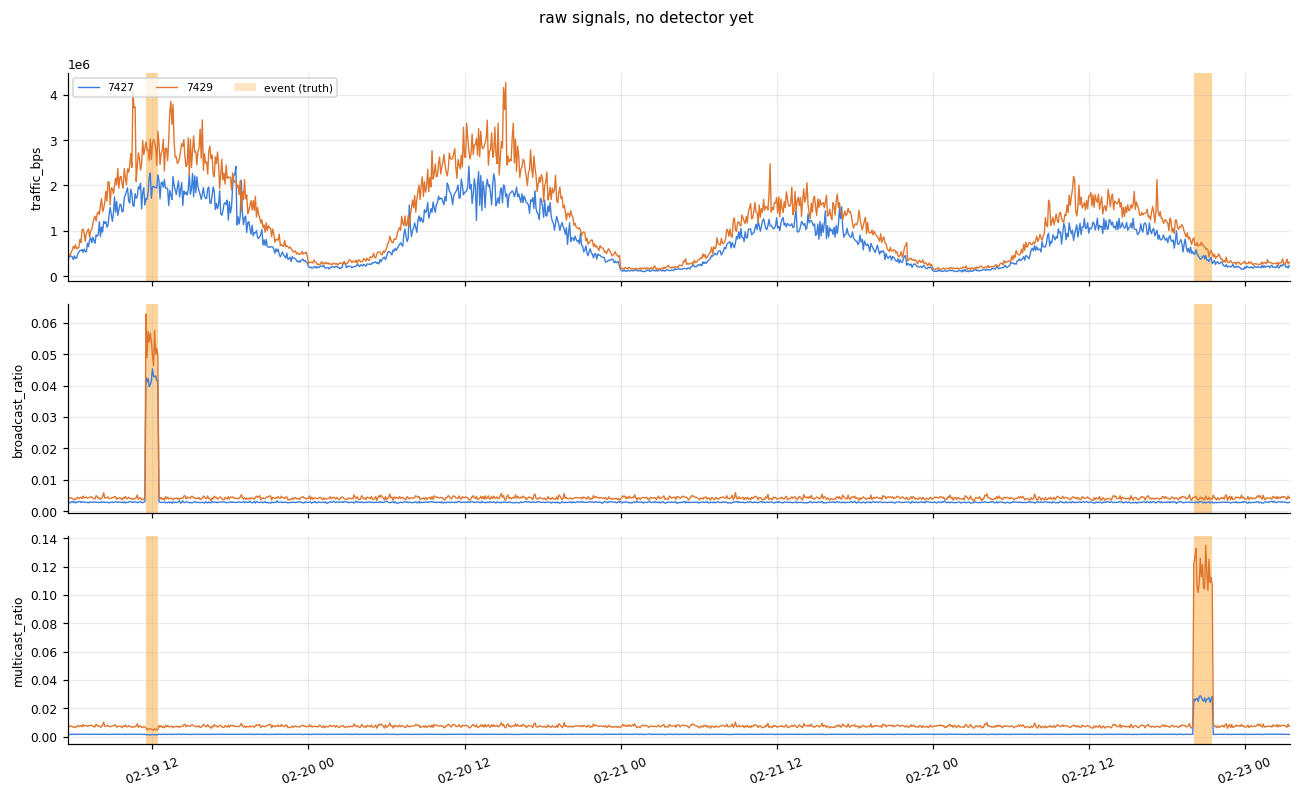

In [6]:
plot_signals(title="raw signals, no detector yet")

The storm and the flooding are obvious on the ratio columns and invisible on `traffic_bps`:
they change the packet *mix*, not the volume. Both hit every port at the same minute, which
is what an L2 problem looks like. The signal you score decides what you can detect, before
any statistics.

## Step 5 — Z-score

$$z_i = (x_i - \bar{x}) / \sigma$$

Computed per port, because a busy uplink would otherwise define normal for a quiet VLAN.

In [7]:
def modified_zscore(x, k=1.4826):
    """(x - median) / (k * MAD), NaN everywhere if the MAD is zero.

    k rescales the MAD to read on the same axis as a standard deviation on normal data.
    A zero MAD means over half the samples are identical, so the function refuses.
    """
    x = np.asarray(x, dtype=float)
    d = x - np.median(x)
    mad = np.median(np.abs(d))
    return d / (k * mad) if mad > 0 else np.full_like(x, np.nan)


def add_scores(data, columns=None, ports=None, kind="z"):
    """Write one score column per signal, computed within each port. Returns the names."""
    columns = COLUMNS if columns is None else columns
    ports = PORTS if ports is None else ports
    made = []
    for col in columns:
        out = f"{kind}_{col}"
        data[out] = np.nan
        for pid in (data["port_id"].unique() if ports == "all" else ports):
            m = data["port_id"] == pid
            v = data.loc[m, col].to_numpy(dtype=float)
            data.loc[m, out] = ss.zscore(v, ddof=0) if kind == "z" else modified_zscore(v)
        made.append(out)
    return made


z_cols = add_scores(df, kind="z")
df.loc[df["port_id"].isin(PORTS), ["timestamp", "port_id"] + COLUMNS + z_cols].head()

,timestamp,port_id,traffic_bps,broadcast_ratio,multicast_ratio,z_traffic_bps,z_broadcast_ratio,z_multicast_ratio
0,2026-02-01 00:00:00,port-id7427,116229.412000,0.003275,0.001820,-1.122321,0.264509,0.098125
1,2026-02-01 00:05:00,port-id7427,101633.060800,0.002638,0.001649,-1.142946,-0.168492,-0.051770
2,2026-02-01 00:10:00,port-id7427,121596.794667,0.002785,0.001671,-1.114737,-0.068581,-0.032209
3,2026-02-01 00:15:00,port-id7427,123970.989067,0.002677,0.001606,-1.111382,-0.141509,-0.088686
4,2026-02-01 00:20:00,port-id7427,92873.944800,0.002693,0.001539,-1.155322,-0.130663,-0.147752


## Step 6 — Cutoff

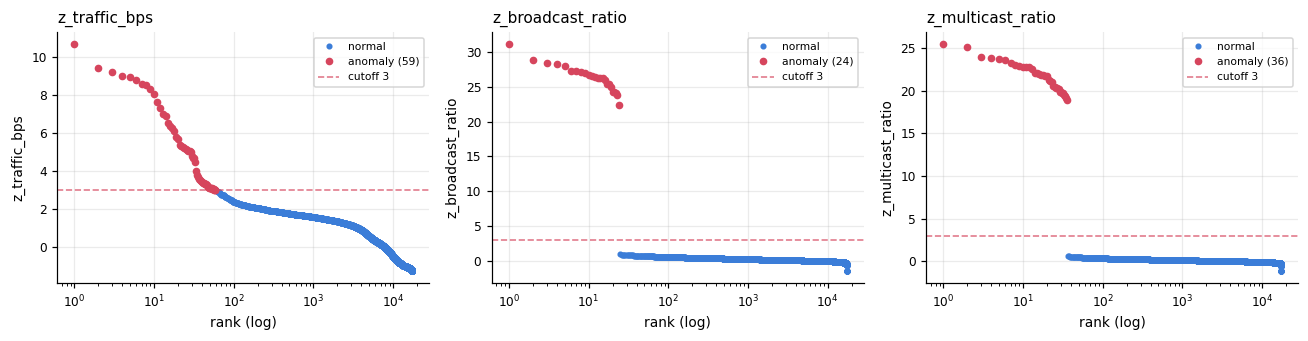

In [8]:
fig, axes = plt.subplots(1, len(COLUMNS), figsize=(4 * len(COLUMNS), 3.2), squeeze=False)
for ax, col in zip(axes[0], COLUMNS):
    plot_ranked(df.loc[df["port_id"].isin(PORTS), f"z_{col}"], name=f"z_{col}", ax=ax)
plt.tight_layout()
plt.show()

The ratio columns have a handful of points far above a flat body, and the cutoff at 3 lands
in empty space. `traffic_bps` descends smoothly through it, so every point near the line is
a coin toss.

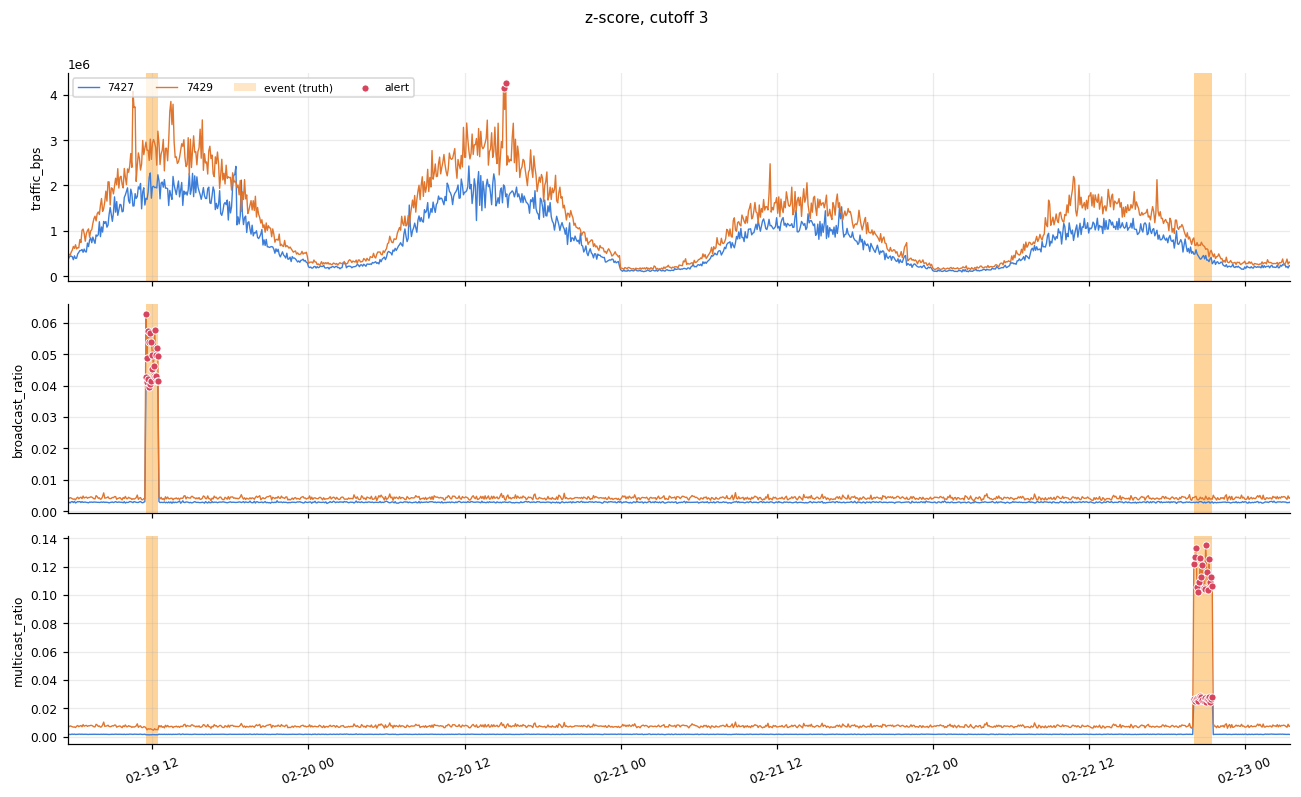

,detector,alerts,true_pos,false_pos,precision,events_caught
0,z traffic_bps,59,32,27,0.542,2/7
1,z broadcast_ratio,24,24,0,1.000,2/7
2,z multicast_ratio,36,36,0,1.000,2/7


In [9]:
alerts_z = {col: df[f"z_{col}"] > THRESHOLD for col in COLUMNS}
plot_signals(alerts=alerts_z, title=f"z-score, cutoff {THRESHOLD:g}")
report({f"z {c}": a for c, a in alerts_z.items()})

Both ratio columns alert only inside labelled windows. `traffic_bps` gets 27 of its 59
alerts wrong, and every one of those lands on a weekday afternoon between 10:00 and 15:00.
Those are the business peak, not an incident. A global mean over 30 days does not model a
metric with a daily and a weekly cycle.

## Step 7 — Check the model

The cutoff carries a probability only if the data is normal. Test it.

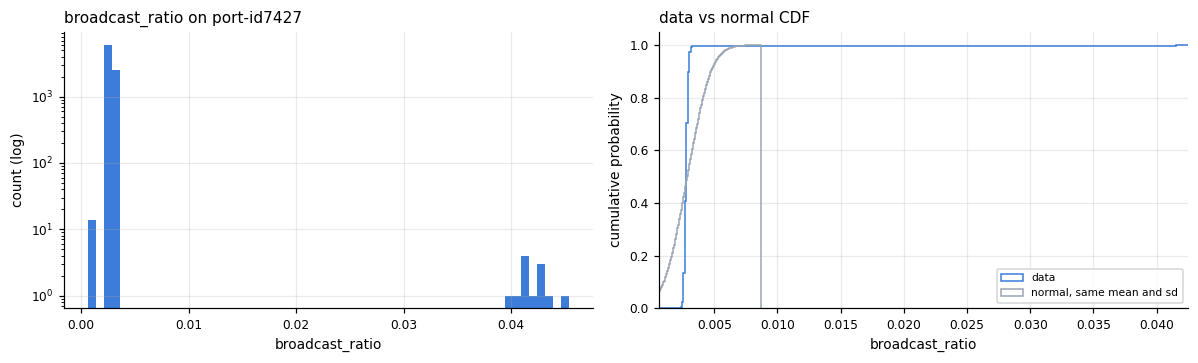

Shapiro-Wilk (n=1000): W=0.0545, p=1.02e-56


In [10]:
col, port = "broadcast_ratio", PORTS[0]
v = df.loc[df["port_id"] == port, col]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(v, bins=60, color=C["signal"])
axes[0].set(yscale="log", xlabel=col, ylabel="count (log)", title=f"{col} on {port}")

axes[1].hist(v, bins=400, density=True, histtype="step", cumulative=True,
             color=C["signal"], label="data")
axes[1].hist(np.random.default_rng(0).normal(v.mean(), v.std(ddof=0), 20_000),
             bins=400, density=True, histtype="step", cumulative=True,
             color=C["muted"], label="normal, same mean and sd")
axes[1].set(xlim=(v.min(), v.quantile(0.9995)), xlabel=col,
            ylabel="cumulative probability", title="data vs normal CDF")
axes[1].legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

stat, p = ss.shapiro(v.sample(1000, random_state=0))
print(f"Shapiro-Wilk (n=1000): W={stat:.4f}, p={p:.2e}")

Not normal, and not close. The alerts were still right, so the ranking survives. What is
lost is the probability: a cutoff of 3 no longer means 0.13% of samples, it means three
standard deviations, and how often that happens is now an empirical question about this
port.

## Step 8 — Where the mean and standard deviation break

Both are computed from the data they judge, so a subpopulation drags them. Aggregate
`traffic_bps` to one value per day, giving 30 points instead of 8,640.

In [11]:
port = PORTS[0]
daily = (df[df["port_id"] == port]
         .assign(date=lambda d: d["timestamp"].dt.floor("D"))
         .groupby("date", as_index=False)
         .agg(mean_bps=("traffic_bps", "mean"),
              event=("event_id", lambda s: ",".join(sorted(set(s.dropna()))))))
daily["weekday"] = daily["date"].dt.day_name().str[:3]

mean, sd = daily["mean_bps"].mean(), daily["mean_bps"].std(ddof=0)
median = daily["mean_bps"].median()
mad_sigma = 1.4826 * np.median(np.abs(daily["mean_bps"] - median))

print(f"mean   {mean:.3e}   sd          {sd:.3e}")
print(f"median {median:.3e}   1.4826*MAD  {mad_sigma:.3e}")
print(f"sd is {sd / mad_sigma:.1f}x the robust scale, and the mean sits below the median")

mean   9.105e+05   sd          2.148e+05
median 1.017e+06   1.4826*MAD  3.511e+04
sd is 6.1x the robust scale, and the mean sits below the median


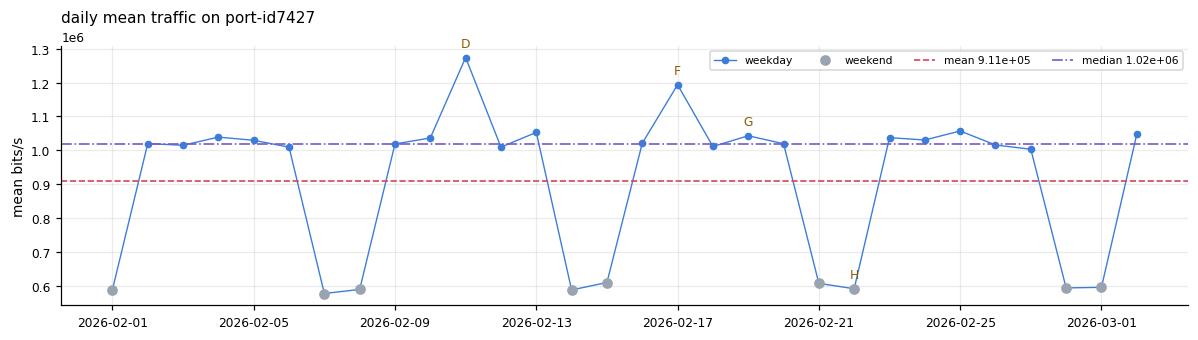

In [12]:
daily["z"] = ss.zscore(daily["mean_bps"], ddof=0)
daily["modz"] = modified_zscore(daily["mean_bps"])

weekend = daily["weekday"].isin(["Sat", "Sun"])
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(daily["date"], daily["mean_bps"], "-o", ms=4, lw=0.9, color=C["signal"], label="weekday")
ax.plot(daily.loc[weekend, "date"], daily.loc[weekend, "mean_bps"], "o", ms=6,
        color=C["muted"], label="weekend")
ax.axhline(mean, color=C["alert"], ls="--", lw=1.1, label=f"mean {mean:.2e}")
ax.axhline(median, color=C["score"], ls="-.", lw=1.1, label=f"median {median:.2e}")
for e in daily.loc[daily["event"] != ""].itertuples():
    ax.annotate(e.event, (e.date, e.mean_bps), fontsize=8, color="#8A5A00",
                xytext=(0, 7), textcoords="offset points", ha="center")
ax.set(ylabel="mean bits/s", title=f"daily mean traffic on {port}")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

The data is bimodal: 9 weekend days near 5.9e5 bits/s, 21 weekdays near 1.02e6. One mean
describes neither mode, and the gap between them inflates the standard deviation. The
denominator of every z-score is now made of a pattern that is not an anomaly.

The modified z-score swaps both moments for order statistics:

$$y_i = (x_i - \tilde{x}) / (k \cdot \mathrm{MAD}), \qquad k = 1.4826$$

The median does not move until over half the sample is contaminated, and the weekend days
are a minority.

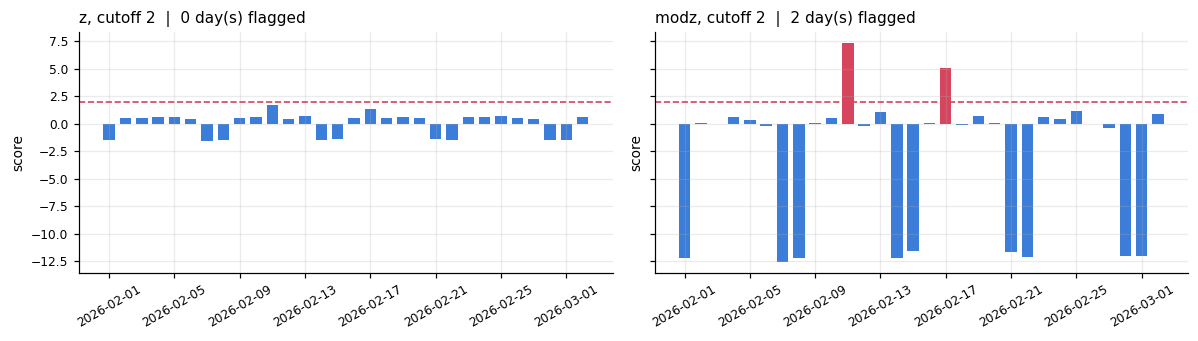

,date,weekday,mean_bps,event,z,modz
10,2026-02-11,Wed,1.274029e+06,D,1.692083,7.315491
16,2026-02-17,Tue,1.193684e+06,F,1.318086,5.027069


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, score in zip(axes, ["z", "modz"]):
    hit = daily[score] > 2
    ax.bar(daily["date"], daily[score], width=0.7, color=np.where(hit, C["alert"], C["signal"]))
    ax.axhline(2, color=C["alert"], ls="--", lw=1.1)
    ax.set(title=f"{score}, cutoff 2  |  {int(hit.sum())} day(s) flagged", ylabel="score")
    ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

daily.loc[(daily["z"] > 2) | (daily["modz"] > 2),
          ["date", "weekday", "mean_bps", "event", "z", "modz"]]

The z-score flags nothing: the weekend cluster made the denominator large enough to swallow
every day. The modified z-score flags two, and both carry a real event, **D** (queue
congestion) and **F** (load-sensitive link issue).

## Step 9 — Where the MAD breaks

Robust is not a free upgrade, and network telemetry walks into its failure constantly.

In [14]:
col = "discard_ratio"
v = df.loc[df["port_id"] == PORTS[0], col]
z = pd.Series(ss.zscore(v, ddof=0), index=v.index)
truth = df.loc[v.index, "event_label"] != "normal"

print(f"{col} on {PORTS[0]}")
print(f"  exactly zero      {(v == 0).mean():.1%}")
print(f"  median {v.median():.6g}   MAD {np.median(np.abs(v - v.median())):.6g}")
print(f"  modified z-score  {'all NaN' if np.isnan(modified_zscore(v)).all() else 'defined'}")
print(f"  plain z > {THRESHOLD:g}     {int((z > THRESHOLD).sum())} alerts, "
      f"{int(((z > THRESHOLD) & truth).sum())} inside a labelled event")

discard_ratio on port-id7427
  exactly zero      95.7%
  median 0   MAD 0
  modified z-score  all NaN
  plain z > 3     44 alerts, 44 inside a labelled event


About 96% of samples are exactly zero, so the median is zero and so is the MAD. The modified
z-score is undefined on a column where the plain z-score is perfect.

Use the modified z-score when the data is a body with a tail. Check the MAD first, because a
NaN column and a quiet column look identical on a dashboard.

## Step 10 — Both scores side by side

In [15]:
add_scores(df, kind="modz")

detectors = {}
for col in COLUMNS:
    detectors[f"z    {col}"] = df[f"z_{col}"] > THRESHOLD
    if df[f"modz_{col}"].notna().any():
        detectors[f"modz {col}"] = df[f"modz_{col}"] > THRESHOLD
    else:
        print(f"skipped modz {col}: MAD is zero on a configured port")

report(detectors).sort_values("precision", ascending=False)

,detector,alerts,true_pos,false_pos,precision,events_caught
2,z broadcast_ratio,24,24,0,1.000,2/7
4,z multicast_ratio,36,36,0,1.000,2/7
1,modz traffic_bps,38,32,6,0.842,2/7
0,z traffic_bps,59,32,27,0.542,2/7
5,modz multicast_ratio,137,37,100,0.270,3/7
3,modz broadcast_ratio,123,25,98,0.203,3/7


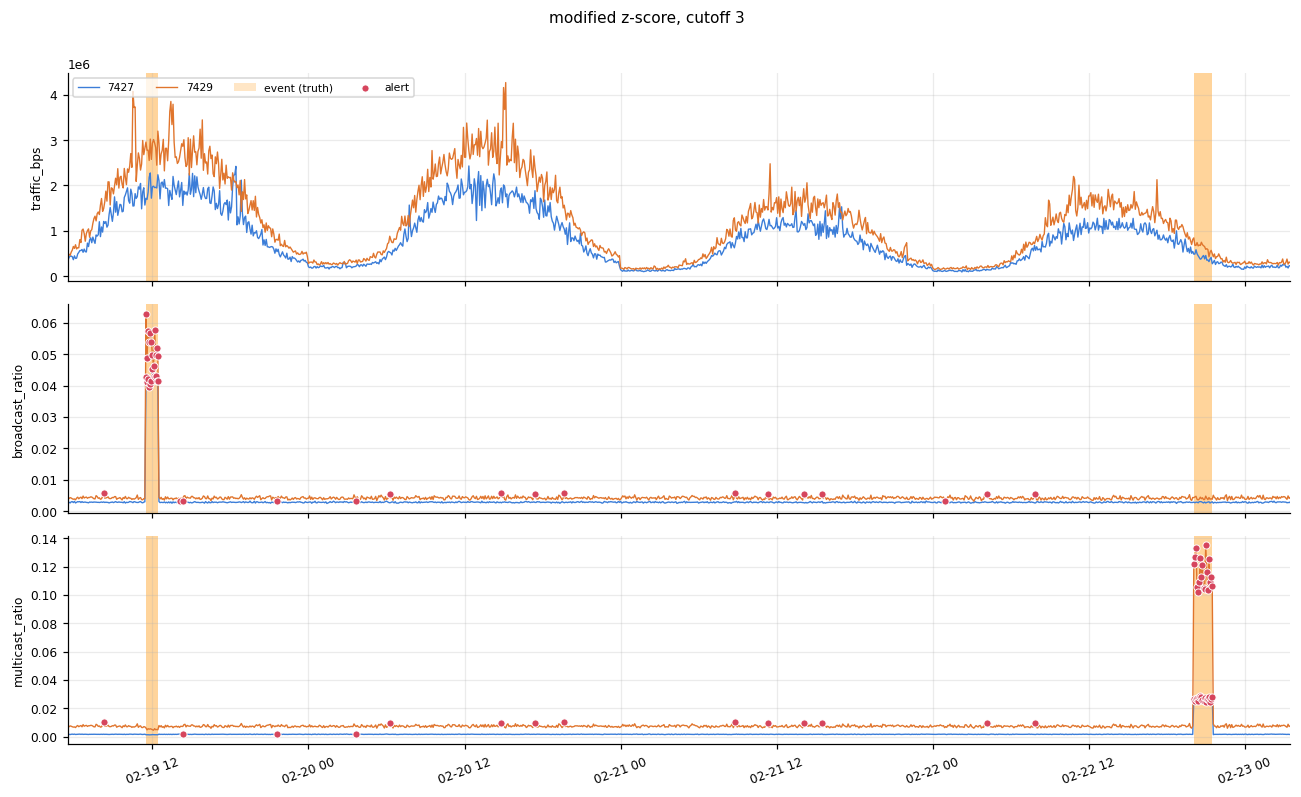

In [16]:
plot_signals(alerts={c: df[f"modz_{c}"] > THRESHOLD for c in COLUMNS},
             title=f"modified z-score, cutoff {THRESHOLD:g}")

At the same cutoff the modified z-score raises five times as many alerts on the ratio
columns. Same mechanism as Step 8, read the other way: the storm inflated the standard
deviation, so the z-score divided by a large number, while the MAD is set by ordinary
samples instead.

That extra sensitivity buys one more event window and costs about a hundred false alarms per
column. Robust means more sensitive, not quieter, and a cutoff tuned for one score is wrong
for the other.

## Exercises

The answers are in the figures after you re-run, not in the text.

1. **Move the cutoff.** Set `THRESHOLD` to `2.0`, then `5.0`, and re-run from Step 5. Which
   signal's precision collapses first? Did the ranked plot predict it?
2. **Add ports.** Put all five in `PORTS`. Does one cutoff still mean the same thing on
   `backup-storage` and `office-vlan`?
3. **Change the signal.** Add `"INERRORS"` to `COLUMNS` and set
   `EVENT_TYPES = ["link_quality_issue"]`, an 8-sample event on `port-id7429`. What does the
   MAD of `INERRORS` tell you before you plot anything?
4. **A different event.** Set `EVENT_TYPES = ["small_packet_scan"]`. A scan raises packet
   count without raising bytes. Build the ratio that expresses that, and score it.

In [17]:
# YOUR CODE HERE

## Summary

**Model** — a global mean over 30 days describes a metric with no cycle. `traffic_bps` has a
daily and a weekly one, so the statistic that worked on `broadcast_ratio` described nothing.

**Score** — the z-score's mean and standard deviation are dragged by the points you are
hunting. The median and MAD survive a contaminated minority, and collapse when the majority
is constant.

**Cutoff** — a cutoff in a gap survives being moved. One inside a dense band splits
near-identical samples on nothing, and the ranked plot shows which you have before any alert.

Nothing here handled seasonality. Every score compared a sample against the whole month,
when the honest comparison is against the same port at the same hour on a comparable day.
That is the next lab.